In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Add, Multiply, Activation, Reshape, Flatten
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [3]:
import keras
import numpy as np
from keras import models
from keras import layers
from keras import optimizers
import matplotlib.pyplot as plt
from keras.optimizers import SGD, Adam
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, SeparableConv2D,AveragePooling2D,GlobalAveragePooling2D,GlobalMaxPooling2D
import os,cv2
from sklearn.model_selection import train_test_split
from keras.callbacks import Callback
from sklearn.metrics import precision_score, recall_score
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau


In [4]:
import albumentations as A

# Data processing
img_data_list = []
labels = []

# Define augmentation techniques
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.2)
])

# Function to process and augment images
def process_images(data_path, label, save_path, num_aug=3):
    os.makedirs(save_path, exist_ok=True)  # Create folder for augmented images

    for dataset in os.listdir(data_path):
        img_path = os.path.join(data_path, dataset)
        input_img = cv2.imread(img_path)

        if input_img is None:
            print(f"Warning: Image {dataset} could not be loaded.")
            continue

        input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        input_img_resize = cv2.resize(input_img, (224, 224))
        input_img_resize = cv2.normalize(input_img_resize, None, 0, 255, cv2.NORM_MINMAX)

        # Add original image to dataset
        img_data_list.append(input_img_resize)
        labels.append(label)

        # Augment and add multiple versions
        for i in range(num_aug):
            augmented = transform(image=input_img_resize)['image']
            img_data_list.append(augmented)  # Add augmented image
            labels.append(label)  # Keep same label

            # Save augmented image
            aug_filename = f"aug_{i}_{dataset}"
            cv2.imwrite(os.path.join(save_path, aug_filename), cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))

# Load and augment data for each class
process_images('/content/drive/MyDrive/major-project/dataset/0-normal/0', 0,
               '/content/drive/MyDrive/major-project/dataset/0-normal/0_Augmented')

process_images('/content/drive/MyDrive/major-project/dataset/1-oesteopenia/1', 1,
               '/content/drive/MyDrive/major-project/dataset/1-oesteopenia/1_Augmented')

process_images('/content/drive/MyDrive/major-project/dataset/2-oestopororsis/2', 2,
               '/content/drive/MyDrive/major-project/dataset/2-oestopororsis/2_Augmented')

In [5]:
print(f"Total images in dataset: {len(img_data_list)}")
print(f"Total labels in dataset: {len(labels)}")

# Optional: Count images per class
unique_labels, counts = np.unique(labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"Class {label}: {count} images")


Total images in dataset: 7788
Total labels in dataset: 7788
Class 0: 3120 images
Class 1: 1496 images
Class 2: 3172 images


In [6]:
# from keras.utils import np_utils
from keras.utils import to_categorical
num_classes = 3
label = to_categorical(labels, num_classes)

In [7]:
# Convert lists to arrays
img_data = np.array(img_data_list)
labels = np.array(labels)

print(f'Image data shape: {img_data.shape}')
print(f'Labels shape: {labels.shape}')


Image data shape: (7788, 224, 224, 3)
Labels shape: (7788,)


In [8]:
print(len(img_data))  # Should be > 0
print(len(label))  # Should be > 0


7788
7788


In [9]:
x_train, x_val, y_train, y_val = train_test_split(img_data, label, test_size=0.2)

# Print the train set
print('Train Set')
print(x_train.shape)
print(y_train.shape)

# Print the validation set
print('Validation Set')
print(x_val.shape)
print(y_val.shape)


Train Set
(6230, 224, 224, 3)
(6230, 3)
Validation Set
(1558, 224, 224, 3)
(1558, 3)


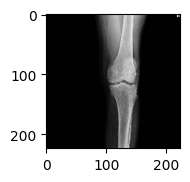

In [11]:
plt.figure(figsize=(8, 8))
for i in range(1, 2):
  plt.subplot(4, 4, i)
  img= x_val[i]
  plt.imshow(img)
plt.show()

In [12]:
from keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Dense, Multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda
from keras import backend as K
from keras.layers import Layer

class ECA(Layer):
    def __init__(self, gamma=2, **kwargs):
        super(ECA, self).__init__(**kwargs)
        self.gamma = gamma

    def build(self, input_shape):
        channels = input_shape[-1]
        self.conv = Conv2D(filters=1, kernel_size=1, kernel_initializer='he_normal', activation='sigmoid')

        # Correct the shape of `gamma`
        self.gamma = self.add_weight(name="gamma", shape=(1, 1, 1, channels),
                                     initializer="ones", trainable=True)

    def call(self, inputs):
        weights = self.conv(inputs)  # (batch, H, W, 1)

        # Apply attention mechanism
        weighted_inputs = Multiply()([inputs, weights])  # (batch, H, W, C)
        scaled_inputs = Multiply()([inputs, self.gamma])  # (batch, H, W, C)
        output = Add()([weighted_inputs, scaled_inputs])  # (batch, H, W, C)

        return output


In [14]:
from keras.layers import Add, Concatenate, Dense, Conv2D, GlobalMaxPooling2D, MaxPooling2D, Input, Flatten
from keras.models import Model

input_layer = Input(shape=(224, 224, 3))

# First block
x = Conv2D(32, (3,3), activation='relu')(input_layer)
x1 = Conv2D(32, (3,3), padding='same', activation='relu')(x)
x2 = Conv2D(32, (3,3), padding='same', activation='relu')(x)
a1 = Add()([x1, x2])
att1 = ECA()(a1)  # Corrected this line
g1 = GlobalMaxPooling2D()(att1)

m1 = MaxPooling2D(pool_size=2, strides=2)(a1)

# Second block
x = Conv2D(32, (3,3), activation='relu')(m1)
x1 = Conv2D(32, (3,3), padding='same', activation='relu')(x)
x2 = Conv2D(32, (3,3), padding='same', activation='relu')(x)
a2 = Add()([x1, x2])
att2 = ECA()(a2)  # Corrected this line
g2 = GlobalMaxPooling2D()(att2)

m2 = MaxPooling2D(pool_size=2, strides=2)(a2)

# Third block
x = Conv2D(32, (3,3), activation='relu')(input_layer)
x1 = Conv2D(32, (3,3), padding='same', activation='relu')(x)
x2 = Conv2D(32, (3,3), padding='same', activation='relu')(x)
a3 = Add()([x1, x2])
att3 = ECA()(a3)  # Corrected this line
g3 = GlobalMaxPooling2D()(att3)

# Flatten the outputs
flatten1 = Flatten()(g1)
flatten2 = Flatten()(g2)
flatten3 = Flatten()(g3)

# Concatenate the flattened outputs
concatenated = Concatenate()([flatten1, flatten2, flatten3])

# Dense layers for classification
dense1 = Dense(512, activation='relu')(concatenated)
dense2 = Dense(256, activation='relu')(dense1)
output = Dense(3, activation='softmax')(dense2)

model = Model(inputs=input_layer, outputs=output)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 222, 222, 32)   │            896 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 222, 222, 32)   │          9,248 │ conv2d_12[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 222, 222, 32)   │          9,248 │ conv2d_12[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_6 (Add)               │ (None, 222, 222, 32)   │              0 │ conv2d_13[0][0],       │
│                           │                        │                │ conv2d_14[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 111, 111, 32)   │              0 │ add_6[0][0]            │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 109, 109, 32)   │          9,248 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 222, 222, 32)   │            896 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 109, 109, 32)   │          9,248 │ conv2d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 109, 109, 32)   │          9,248 │ conv2d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 222, 222, 32)   │          9,248 │ conv2d_20[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 222, 222, 32)   │          9,248 │ conv2d_20[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_8 (Add)               │ (None, 109, 109, 32)   │              0 │ conv2d_17[0][0],       │
│                           │                        │                │ conv2d_18[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_10 (Add)              │ (None, 222, 222, 32)   │              0 │ conv2d_21[0][0],       │
│                           │                        │                │ conv2d_22[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ eca_3 (ECA)               │ (None, 222, 222, 32)   │             65 │ add_6[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ eca_4 (ECA)               │ (None, 109, 109, 32)   │             65 │ add_8[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ eca_5 (ECA)               │ (None, 222, 222, 32)   │             65 │ add_10[0][0]           │
├──────────────────────

 Total params: 248,486 (970.65 KB)

 Trainable params: 248,486 (970.65 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from keras import optimizers as optim


# Reduce learning rate when validation accuracy stops improving
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Early stopping with lower patience & min_delta
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=15,         # Reduced from 30 to 15
    min_delta=0.0005,    # Detects smaller improvements
    restore_best_weights=True
)

checkpoint = ModelCheckpoint('/content/drive/MyDrive/major-project/checkpoint-v1/'+'-{epoch:02d}.h5', monitor='val_accuracy', save_best_only=True)

# Try Adam with higher LR or switch to SGD
model.compile(
    loss='categorical_crossentropy',
    optimizer=optim.Adam(learning_rate=0.001),  # Increased from 0.0001
    metrics=['accuracy']
)

history = model.fit(x_train, y_train,
                    epochs=80, batch_size=32,  # Increased batch size
                    validation_data=(x_val, y_val),
                    callbacks=[early_stopping, checkpoint],
                    verbose=1)



Epoch 1/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.4416 - loss: 15.4360

195/195 ━━━━━━━━━━━━━━━━━━━━ 79s 321ms/step - accuracy: 0.4419 - loss: 15.3810 - val_accuracy: 0.5706 - val_loss: 0.9833
Epoch 2/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5763 - loss: 0.8955

195/195 ━━━━━━━━━━━━━━━━━━━━ 56s 250ms/step - accuracy: 0.5763 - loss: 0.8954 - val_accuracy: 0.6297 - val_loss: 0.8493
Epoch 3/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6188 - loss: 0.8275

195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 252ms/step - accuracy: 0.6188 - loss: 0.8274 - val_accuracy: 0.6816 - val_loss: 0.6728
Epoch 4/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6538 - loss: 0.7586

195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 252ms/step - accuracy: 0.6539 - loss: 0.7585 - val_accuracy: 0.7112 - val_loss: 0.6675
Epoch 5/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6780 - loss: 0.7021

...

195/195 ━━━━━━━━━━━━━━━━━━━━ 80s 239ms/step - accuracy: 0.8558 - loss: 0.3226 - val_accuracy: 0.7965 - val_loss: 0.5159
Epoch 34/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 249ms/step - accuracy: 0.8530 - loss: 0.3450 - val_accuracy: 0.7869 - val_loss: 0.5139
Epoch 35/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8676 - loss: 0.3094

195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 250ms/step - accuracy: 0.8676 - loss: 0.3094 - val_accuracy: 0.8010 - val_loss: 0.4958
Epoch 36/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8718 - loss: 0.2916

195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 250ms/step - accuracy: 0.8718 - loss: 0.2917 - val_accuracy: 0.8132 - val_loss: 0.4749
Epoch 37/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 48s 246ms/step - accuracy: 0.8664 - loss: 0.3034 - val_accuracy: 0.7920 - val_loss: 0.5276
Epoch 38/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 83s 250ms/step - accuracy: 0.8741 - loss: 0.2940 - val_accuracy: 0.7869 - val_loss: 0.5428
Epoch 39/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 79s 237ms/step - accuracy: 0.8805 - loss: 0.2710 - val_accuracy: 0.8113 - val_loss: 0.5111
Epoch 40/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 237ms/step - accuracy: 0.8905 - loss: 0.2552 - val_accuracy: 0.7991 - val_loss: 0.5257
Epoch 41/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 237ms/step - accuracy: 0.8971 - loss: 0.2456 - val_accuracy: 0.8100 - val_loss: 0.4913
Epoch 42/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 237ms/step - accuracy: 0.8849 - loss: 0.2655 - val_accuracy: 0.8055 - val_loss: 0.5373
Epoch 43/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 237ms/step - accuracy: 0.8844 - loss: 0.280

195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 237ms/step - accuracy: 0.8933 - loss: 0.2599 - val_accuracy: 0.8177 - val_loss: 0.4659
Epoch 45/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 237ms/step - accuracy: 0.8945 - loss: 0.2403 - val_accuracy: 0.8074 - val_loss: 0.5497
Epoch 46/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 81s 232ms/step - accuracy: 0.8937 - loss: 0.2474 - val_accuracy: 0.7875 - val_loss: 0.5222
Epoch 47/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 45s 231ms/step - accuracy: 0.8968 - loss: 0.2569 - val_accuracy: 0.8042 - val_loss: 0.5555
Epoch 48/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9028 - loss: 0.2327

195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.9028 - loss: 0.2327 - val_accuracy: 0.8261 - val_loss: 0.4470
Epoch 49/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 81s 238ms/step - accuracy: 0.9085 - loss: 0.2232 - val_accuracy: 0.8132 - val_loss: 0.5109
Epoch 50/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 237ms/step - accuracy: 0.8986 - loss: 0.2345 - val_accuracy: 0.8254 - val_loss: 0.5314
Epoch 51/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 79s 224ms/step - accuracy: 0.9000 - loss: 0.2316 - val_accuracy: 0.8126 - val_loss: 0.5631
Epoch 52/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 224ms/step - accuracy: 0.9212 - loss: 0.1941 - val_accuracy: 0.8254 - val_loss: 0.5302
Epoch 53/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 44s 227ms/step - accuracy: 0.9014 - loss: 0.2359 - val_accuracy: 0.8068 - val_loss: 0.5211
Epoch 54/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 225ms/step - accuracy: 0.9086 - loss: 0.2172 - val_accuracy: 0.8158 - val_loss: 0.5556
Epoch 55/80
195/195 ━━━━━━━━━━━━━━━━━━━━ 82s 224ms/step - accuracy: 0.9223 - loss: 0.187

In [27]:
# Save the entire model (architecture + weights)
model.save("/content/drive/MyDrive/major-project/checkpoint-v1/saved-h5.h5")

print("Model saved successfully at /content/drive/MyDrive/major-project/checkpoint-v1/saved-h5.h5")


TypeError: Unable to serialize <Variable path=eca_3/gamma, shape=(1, 1, 1, 32), dtype=float32, value=[[[[1.0321372  0.95228755 0.8970718  1.1209168  0.8287537  1.0051148
    0.882196   1.0198814  0.87129486 0.85983896 0.8664125  0.82975596
    0.8546487  1.0019492  0.9172446  0.8523944  0.89215595 0.95808226
    0.8647923  0.8710486  0.83438325 0.9219954  0.7853828  0.98415726
    0.8792836  0.89513016 0.8419363  0.9047912  0.8514535  0.91437155
    0.9901153  0.7752085 ]]]]> to JSON. Unrecognized type <class 'keras.src.backend.Variable'>.

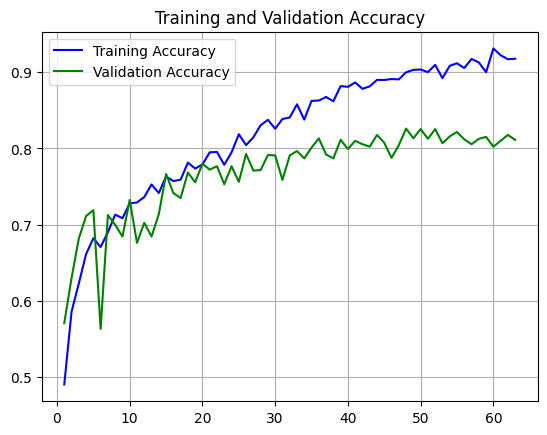

In [17]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'g', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid()
plt.legend()
plt.show()


In [25]:
loss, accuracy = model.evaluate(x_val, y_val, verbose=1)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")


49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.5970 - loss: 1.1892
Validation Accuracy: 57.51%


In [6]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Multiply, Add
from tensorflow.keras.models import load_model

@tf.keras.utils.register_keras_serializable()
class ECA(Layer):
    def __init__(self, gamma=2, **kwargs):
        super(ECA, self).__init__(**kwargs)
        self.gamma = gamma

    def build(self, input_shape):
        channels = input_shape[-1]
        self.conv = Conv2D(filters=1, kernel_size=1, kernel_initializer='he_normal', activation='sigmoid')
        self.gamma = self.add_weight(name="gamma", shape=(1, 1, 1, channels),
                                     initializer="ones", trainable=True)

    def call(self, inputs):
        attention = self.conv(inputs)
        return Multiply()([inputs, attention])

    def get_config(self):
        config = super().get_config()
        config.update({"gamma": self.gamma})
        return config


In [7]:
custom_objects = {"ECA": ECA}

# Load the model with custom_objects
model = load_model('/content/drive/MyDrive/major-project/checkpoint-v1/saved-v1.keras',
                   custom_objects=custom_objects)
model.save('/content/drive/MyDrive/major-project/checkpoint-v1/saved-v1.keras')



In [8]:
import numpy as np
from keras.models import load_model

# Load test data (modify path as needed)
# If using a dataset like CIFAR-10, load like this:
# from tensorflow.keras.datasets import cifar10
# (_, _), (x_test, y_test) = cifar10.load_data()

# If using custom test data, make sure it's loaded properly
# Example: (x_test, y_test) = np.load("/path/to/test_data.npz")

# Ensure x_test is preprocessed the same way as during training

# Load the trained model
model = load_model('/content/drive/MyDrive/major-project/checkpoint-v1/saved-v1.keras')

# Ensure `y_test` is available
# if 'y_val' not in locals():
#     raise ValueError("y_test is not defined. Load your test dataset before running this script.")

# Get the ground truth labels (convert from one-hot encoding if necessary)
ground_truth = np.argmax(y_val, axis=1) if len(y_val.shape) > 1 else y_val

# Get the model's predictions
predictions = model.predict(x_val, batch_size=32)  # Adjust batch size if needed
predicted_classes = np.argmax(predictions, axis=1)

# Find misclassified samples
errors = np.where(predicted_classes != ground_truth)[0]

# Print the number of errors
print(f"No of errors = {len(errors)}/{len(y_val)}")



NameError: name 'y_val' is not defined

In [ ]:
from sklearn.metrics import classification_report
target_names = ['Normal', 'Osteopenia', 'Osteoporosis']  # Provide string names for classes
print(classification_report(ground_truth, predicted_classes, target_names=target_names))

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step


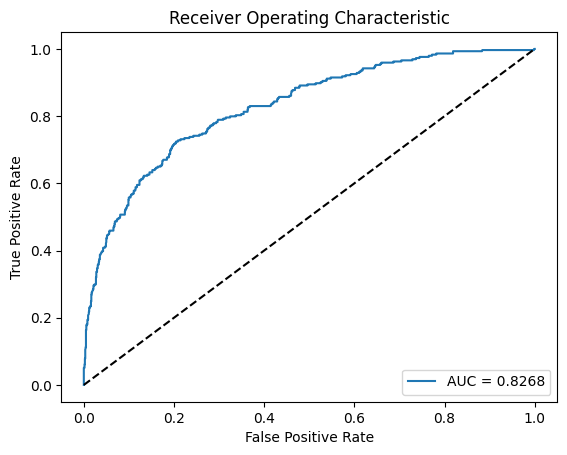

In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_pred_proba = model.predict(x_val)
fpr, tpr, thresholds = roc_curve(y_val[:, 1], y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label='AUC = %0.4f' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()